<a href="https://colab.research.google.com/github/RishankSoni/es335-assignment-3/blob/main/ML_Assignment3_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

In [62]:
np.random.seed(1337)

def make_moons_custom(n_samples=500, noise=0.2):
    """Generate a make_moons-like dataset with given noise."""
    n_samples_out = n_samples // 2
    n_samples_in = n_samples - n_samples_out

    theta_outer = np.linspace(0, np.pi, n_samples_out)
    x_outer = np.stack([np.cos(theta_outer), np.sin(theta_outer)], axis=1)

    theta_inner = np.linspace(0, np.pi, n_samples_in)
    x_inner = np.stack([1 - np.cos(theta_inner), 1 - np.sin(theta_inner) - 0.5], axis=1)

    X = np.vstack([x_outer, x_inner])
    y = np.hstack([np.zeros(n_samples_out), np.ones(n_samples_in)])

    X += noise * np.random.randn(*X.shape)
    return X, y

def standardize_train_test(X_train, X_test):
    """Standardize using train statistics."""
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std

def split_train_val(X, y, val_ratio=0.2):
    """Split into training and validation sets."""
    n_total = X.shape[0]
    n_val = int(n_total * val_ratio)
    indices = np.random.permutation(n_total)
    val_idx, train_idx = indices[:n_val], indices[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

In [63]:
X_train_02, y_train_02 = make_moons_custom(500, noise=0.2)
X_test_02, y_test_02 = make_moons_custom(500, noise=0.2)

X_train_02_std, X_test_02_std = standardize_train_test(X_train_02, X_test_02)

X_train_main, y_train_main, X_val_main, y_val_main = split_train_val(X_train_02_std, y_train_02)

X_test_01, y_test_01 = make_moons_custom(500, noise=0.1)
X_test_03, y_test_03 = make_moons_custom(500, noise=0.3)

X_test_01_std = (X_test_01 - X_train_02.mean(axis=0)) / X_train_02.std(axis=0)
X_test_03_std = (X_test_03 - X_train_02.mean(axis=0)) / X_train_02.std(axis=0)

print("Train:", X_train_main.shape, "Val:", X_val_main.shape, "Test:", X_test_02_std.shape)

Train: (400, 2) Val: (100, 2) Test: (500, 2)


In [64]:
# Model 1: MLP with hidden layer

# noise = 0.2

mlp_es = MLPClassifier(
    hidden_layer_sizes=(50,25),   # one hidden layer with 50 neurons (can tune)
    activation='relu',
    solver='adam',
    early_stopping=True,
    n_iter_no_change=50,        # patience = 50
    validation_fraction=0.2,    # internal val split for early stopping
    random_state=1337,
    max_iter=2000
)

mlp_es.fit(X_train_02_std, y_train_02)

acc_02_m1 = accuracy_score(y_test_02, mlp_es.predict(X_test_02_std))

acc_01_m1 = accuracy_score(y_test_01, mlp_es.predict(X_test_01_std))

acc_03_m1 = accuracy_score(y_test_03, mlp_es.predict(X_test_03_std))

para_m1 = sum(w.size for w in mlp_es.coefs_) + sum(b.size for b in mlp_es.intercepts_)

In [65]:
# Model 2: MLP with L1 regularization

seed = 1337
np.random.seed(seed)
torch.manual_seed(seed)

lambdas = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4]
n_epochs = 1000            # adjust if necessary
batch_size = 64
lr = 1e-3
hidden_dim = 50
device = torch.device("cpu")

def to_tensor(x, dtype=torch.float32):
    return torch.from_numpy(x.astype(np.float32)).to(device)

X_tr = to_tensor(X_train_main)
y_tr = torch.from_numpy(y_train_main.astype(np.int64)).to(device)

X_val = to_tensor(X_val_main)
y_val = torch.from_numpy(y_val_main.astype(np.int64)).to(device)

X_test02 = to_tensor(X_test_02_std)
y_test02 = torch.from_numpy(y_test_02.astype(np.int64)).to(device)

X_test01 = to_tensor(X_test_01_std)
y_test01 = torch.from_numpy(y_test_01.astype(np.int64)).to(device)

X_test03 = to_tensor(X_test_03_std)
y_test03 = torch.from_numpy(y_test_03.astype(np.int64)).to(device)

X_train_full = to_tensor(X_train_02_std)
y_train_full = torch.from_numpy(y_train_02.astype(np.int64)).to(device)

class SimpleMLP(nn.Module):
    def __init__(self, in_dim=2, hidden1=50, hidden2=25):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 2)   # output layer (2 classes)
        self.act = nn.ReLU()
    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)
        return x

# ---- Utility: compute L1 of weight parameters (exclude biases if you want) ----
def l1_penalty(model):
    l1 = torch.tensor(0.0, device=device)
    for name, p in model.named_parameters():
        if 'weight' in name:   # include only weights (skip biases)
            l1 = l1 + torch.sum(torch.abs(p))
    return l1

# ---- Utility: layerwise sparsity (fraction of weights close to zero) ----
def layerwise_sparsity(model, threshold=1e-6):
    spars = []
    for name, p in model.named_parameters():
        if 'weight' in name:
            vals = p.detach().cpu().numpy()
            spars.append(np.mean(np.abs(vals) < threshold))
    return spars

# ---- Training loop for one lambda ----
def train_model_with_l1(lambda_l1):
    model = SimpleMLP(in_dim=2).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_auc = -np.inf
    best_state = None

    n_train = X_tr.shape[0]
    n_batches = int(np.ceil(n_train / batch_size))

    for epoch in range(n_epochs):
        # shuffle
        perm = np.random.permutation(n_train)
        model.train()
        for b in range(n_batches):
            idx = perm[b*batch_size:(b+1)*batch_size]
            xb = X_tr[idx]
            yb = y_tr[idx]

            logits = model(xb)
            loss = criterion(logits, yb)

            # add L1 penalty
            l1 = l1_penalty(model)
            loss = loss + lambda_l1 * l1

            opt.zero_grad()
            loss.backward()
            opt.step()

        # Validation AUROC
        model.eval()
        with torch.no_grad():
            logits_val = model(X_val)
            probs_val = torch.softmax(logits_val, dim=1)[:,1].cpu().numpy()
        val_auc = roc_auc_score(y_val.cpu().numpy(), probs_val)

        # keep best
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}

    # load best state
    model.load_state_dict(best_state)
    return model, best_val_auc

# ---- Run grid over lambdas ----
models = []
val_aucs = []
sparsities = []

for lam in lambdas:
    print(f"Training λ = {lam} ...")
    model, val_auc = train_model_with_l1(lam)
    models.append(model)
    val_aucs.append(val_auc)
    sparsities.append(layerwise_sparsity(model, threshold=1e-6))
    print(f"  val AUROC = {val_auc:.4f}, layerwise sparsity = {sparsities[-1]}")

# ---- Select best lambda by validation AUROC ----
best_idx = int(np.argmax(val_aucs))
best_lambda = lambdas[best_idx]
best_model = models[best_idx]
print(f"\nBest λ = {best_lambda}, val AUROC = {val_aucs[best_idx]:.4f}")

# ---- Evaluate on test sets (accuracies) ----
def predict_probs(model, X):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
    return probs

yhat02 = (predict_probs(best_model, X_test02) >= 0.5).astype(int)
acc_02_m2 = accuracy_score(y_test02.cpu().numpy(), yhat02)

yhat01 = (predict_probs(best_model, X_test01) >= 0.5).astype(int)
acc_01_m2 = accuracy_score(y_test01.cpu().numpy(), yhat01)

yhat03 = (predict_probs(best_model, X_test03) >= 0.5).astype(int)
acc_03_m2 = accuracy_score(y_test03.cpu().numpy(), yhat03)

para_m2 = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

# ---- Layerwise sparsity report for all lambdas ----
for lam, s in zip(lambdas, sparsities):
    print(f"λ={lam:.0e} -> layer sparsity (fraction zeros): {s}")

Training λ = 1e-06 ...
  val AUROC = 0.9924, layerwise sparsity = [np.float64(0.0), np.float64(0.0008), np.float64(0.0)]
Training λ = 3e-06 ...
  val AUROC = 0.9912, layerwise sparsity = [np.float64(0.0), np.float64(0.0032), np.float64(0.0)]
Training λ = 1e-05 ...
  val AUROC = 0.9944, layerwise sparsity = [np.float64(0.0), np.float64(0.0048), np.float64(0.0)]
Training λ = 3e-05 ...
  val AUROC = 0.9928, layerwise sparsity = [np.float64(0.0), np.float64(0.0032), np.float64(0.0)]
Training λ = 0.0001 ...
  val AUROC = 0.9948, layerwise sparsity = [np.float64(0.01), np.float64(0.004), np.float64(0.04)]
Training λ = 0.0003 ...
  val AUROC = 0.9952, layerwise sparsity = [np.float64(0.0), np.float64(0.0016), np.float64(0.0)]

Best λ = 0.0003, val AUROC = 0.9952
λ=1e-06 -> layer sparsity (fraction zeros): [np.float64(0.0), np.float64(0.0008), np.float64(0.0)]
λ=3e-06 -> layer sparsity (fraction zeros): [np.float64(0.0), np.float64(0.0032), np.float64(0.0)]
λ=1e-05 -> layer sparsity (fraction 

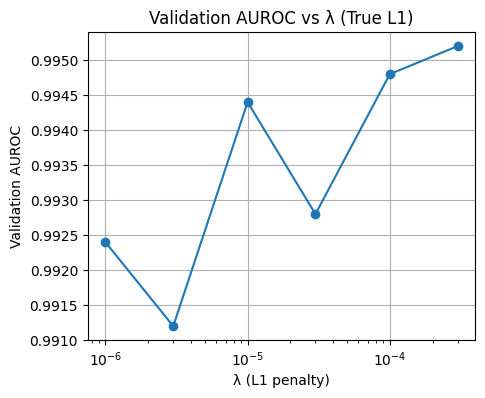

In [66]:
# ---- Plot validation AUROC vs lambda ----
plt.figure(figsize=(5,4))
plt.plot(lambdas, val_aucs, marker='o')
plt.xscale('log')
plt.xlabel('λ (L1 penalty)')
plt.ylabel('Validation AUROC')
plt.title('Validation AUROC vs λ (True L1)')
plt.grid(True)
plt.show()

In [67]:
# -----------------------------
# 1. Create imbalanced training set (70:30)
# -----------------------------
np.random.seed(1337)
torch.manual_seed(1337)

# Suppose X_train_02, y_train_02, X_test_02, y_test_02 already exist from previous code
class0_idx = np.where(y_train_02 == 0)[0]
class1_idx = np.where(y_train_02 == 1)[0]

n0 = int(0.7 * len(y_train_02))
n1 = len(y_train_02) - n0
selected_idx = np.concatenate([
    np.random.choice(class0_idx, int(0.7 * n0), replace=False),
    np.random.choice(class1_idx, int(0.3 * n1), replace=False)
])
X_train_imb, y_train_imb = X_train_02[selected_idx], y_train_02[selected_idx]

# Standardize using train stats
scaler = StandardScaler().fit(X_train_imb)
X_train_imb_std = scaler.transform(X_train_imb)
X_test_02_std = scaler.transform(X_test_02)

# Convert to torch tensors
X_train_t = torch.tensor(X_train_imb_std, dtype=torch.float32)
y_train_t = torch.tensor(y_train_imb.reshape(-1, 1), dtype=torch.float32)
X_test_t = torch.tensor(X_test_02_std, dtype=torch.float32)
y_test_t = torch.tensor(y_test_02.reshape(-1, 1), dtype=torch.float32)

# -----------------------------
# 2. Define the model (same as before)
# -----------------------------
class L1MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = L1MLP(input_dim=2, hidden_dim=50)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# 3. Train with L1 regularization
# -----------------------------
lambda_l1 = 1e-4
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    l1_penalty = sum(torch.abs(p).sum() for p in model.parameters())
    loss += lambda_l1 * l1_penalty

    loss.backward()
    optimizer.step()

# -----------------------------
# 4. Evaluate accuracy & AUROC
# -----------------------------
with torch.no_grad():
    y_pred = model(X_test_t).numpy().flatten()
    y_pred_cls = (y_pred > 0.5).astype(int)

acc_imb = accuracy_score(y_test_02, y_pred_cls)
auc_imb = roc_auc_score(y_test_02, y_pred)

print(f"Test Accuracy (imbalanced train): {acc_imb:.3f}")
print(f"Test AUROC (imbalanced train): {auc_imb:.3f}")

Test Accuracy (imbalanced train): 0.906
Test AUROC (imbalanced train): 0.989


In [68]:
# Model 3: MLP with L2 regularization

alphas = [0.0001, 0.001, 0.01, 0.1, 1]
best_acc = 0
best_alpha = None
best_model3 = None

for alpha in alphas:
    mlp = MLPClassifier(hidden_layer_sizes=(50,25),
                        activation='relu',
                        solver='adam',
                        alpha=alpha,
                        random_state=1337,
                        max_iter=2000)
    mlp.fit(X_train_main, y_train_main)
    val_acc = accuracy_score(y_val_main, mlp.predict(X_val_main))
    if val_acc > best_acc:
        best_acc = val_acc
        best_alpha = alpha
        best_model3 = mlp

print(f"Best alpha (L2 penalty): {best_alpha:.4f}, Validation accuracy: {best_acc:.4f}")

acc_02_m3 = accuracy_score(y_test_02, best_model3.predict(X_test_02_std))
acc_01_m3 = accuracy_score(y_test_01, best_model3.predict(X_test_01_std))
acc_03_m3 = accuracy_score(y_test_03, best_model3.predict(X_test_03_std))
para_m3 = sum(coef.size for coef in best_model3.coefs_) + sum(inter.size for inter in best_model3.intercepts_)

Best alpha (L2 penalty): 0.0001, Validation accuracy: 0.9800


In [69]:
# Model 4: Logistic Regression

# --- Step 1: Generate polynomial features (degree 2 for x₁x₂, x₁², etc.) ---
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_02_std)
X_val_poly = poly.transform(X_val_main)
X_test_poly = poly.transform(X_test_02_std)
X_test01_poly = poly.transform(X_test_01_std)
X_test03_poly = poly.transform(X_test_03_std)

# --- Step 2: Train logistic regression (with L2 regularization) ---
logreg = LogisticRegression(max_iter=2000, random_state=1337)
logreg.fit(X_train_poly, y_train_02)

# --- Step 3: Evaluate accuracies ---
y_test_pred = logreg.predict(X_test_poly)
y_test01_pred = logreg.predict(X_test01_poly)
y_test03_pred = logreg.predict(X_test03_poly)

acc_02_m4 = accuracy_score(y_test_02, y_test_pred)
acc_01_m4 = accuracy_score(y_test_01, y_test01_pred)
acc_03_m4 = accuracy_score(y_test_03, y_test03_pred)
para_m4 = sum(coef.size for coef in logreg.coef_) + logreg.intercept_.size

In [70]:
data = {
    "Model": [
        "MLP (Early Stopping)",
        "MLP (L1 Regularization)",
        "MLP (L2 Regularization)",
        "Logistic Regression"
    ],
    "Params": [
        para_m1,
        para_m2,
        para_m3,
        para_m4
    ],
    "Acc (Noise=0.2)": [
        acc_02_m1,
        acc_02_m2,
        acc_02_m3,
        acc_02_m4
    ],
    "Acc (Noise=0.1)": [
        acc_01_m1,
        acc_01_m2,
        acc_01_m3,
        acc_01_m4
    ],
    "Acc (Noise=0.3)": [
        acc_03_m1,
        acc_03_m2,
        acc_03_m3,
        acc_03_m4
    ]
}

results_df = pd.DataFrame(data)

results_df[["Acc (Noise=0.2)", "Acc (Noise=0.1)", "Acc (Noise=0.3)"]] = results_df[
    ["Acc (Noise=0.2)", "Acc (Noise=0.1)", "Acc (Noise=0.3)"]
].round(3)

print(results_df.to_string(index=False))

                  Model  Params  Acc (Noise=0.2)  Acc (Noise=0.1)  Acc (Noise=0.3)
   MLP (Early Stopping)    1451            0.918            0.942            0.878
MLP (L1 Regularization)    1477            0.976            0.998            0.908
MLP (L2 Regularization)    1451            0.852            0.998            0.910
    Logistic Regression       6            0.846            0.876            0.842


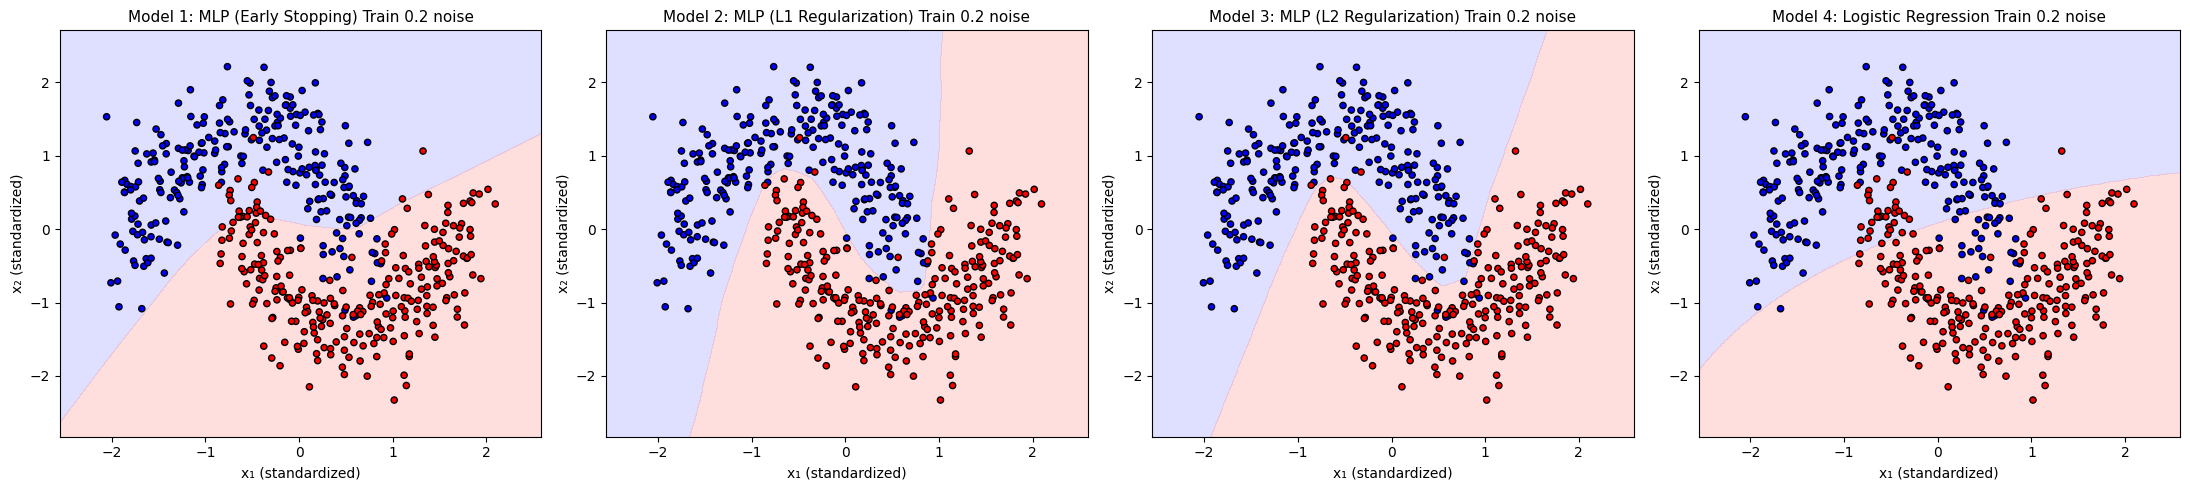

In [71]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x_min, x_max = X_train_02_std[:, 0].min() - 0.5, X_train_02_std[:, 0].max() + 0.5
y_min, y_max = X_train_02_std[:, 1].min() - 0.5, X_train_02_std[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]

# --- Model 1 predictions ---
Z1 = mlp_es.predict_proba(grid)[:, 1].reshape(xx.shape)

# --- Model 2 predictions (PyTorch L1 MLP) ---
probs2 = predict_probs(best_model, torch.from_numpy(grid.astype(np.float32)).to(device))
Z2 = (probs2 >= 0.5).astype(int).reshape(xx.shape)

# --- Model 3 predictions (L2 MLP) ---
Z3 = mlp.predict(grid).reshape(xx.shape)

# --- Model 4 predictions (Logistic Regression with polynomial features) ---
Z4 = logreg.predict(poly.transform(grid)).reshape(xx.shape)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
titles = [
    "Model 1: MLP (Early Stopping) Train 0.2 noise",
    "Model 2: MLP (L1 Regularization) Train 0.2 noise",
    "Model 3: MLP (L2 Regularization) Train 0.2 noise",
    "Model 4: Logistic Regression Train 0.2 noise"
]

Z_list = [Z1, Z2, Z3, Z4]
for ax, Z, title in zip(axes, Z_list, titles):
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap='bwr', alpha=0.25)
    ax.scatter(X_train_02_std[:, 0], X_train_02_std[:, 1],
               c=y_train_02, cmap='bwr', edgecolor='k', s=20)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x₁ (standardized)")
    ax.set_ylabel("x₂ (standardized)")

plt.tight_layout()
plt.show()

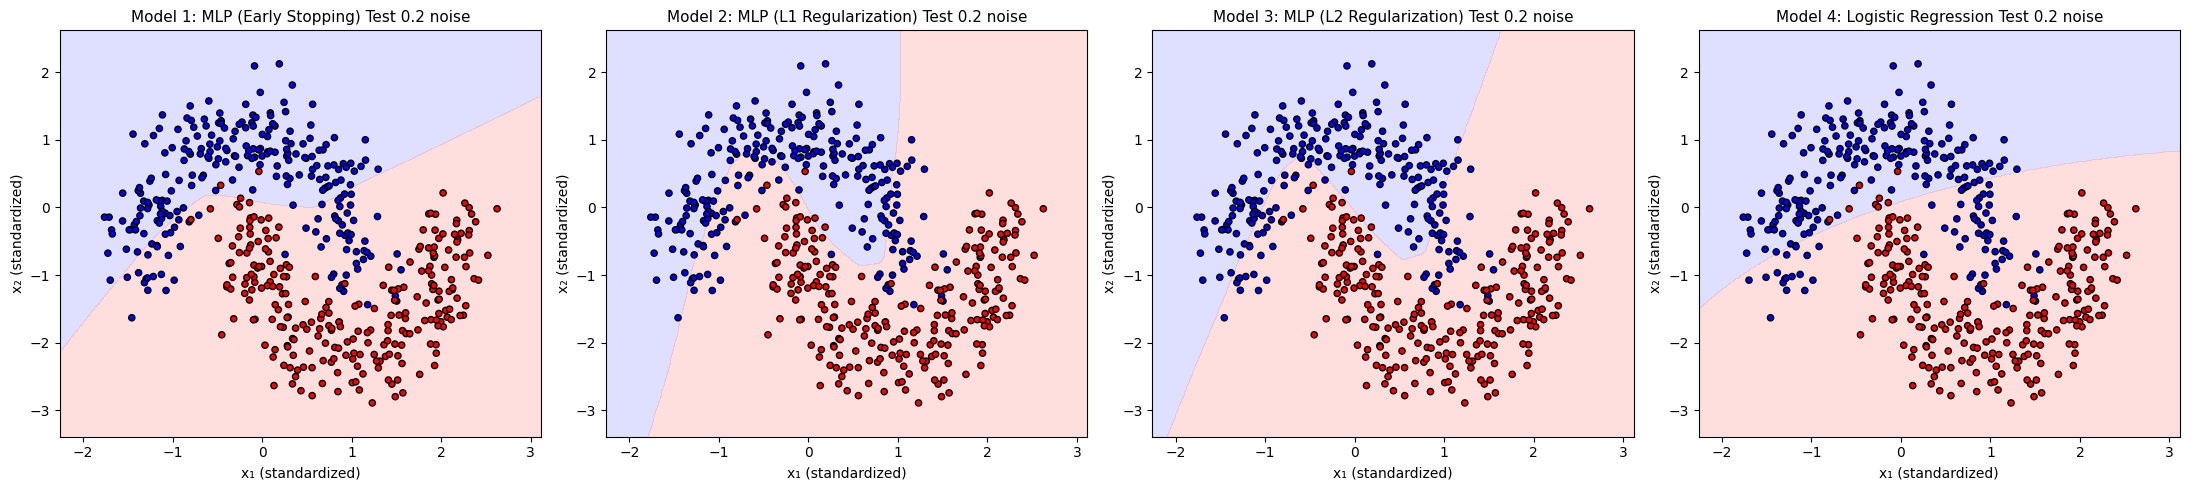

In [72]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x_min, x_max = X_test_02_std[:, 0].min() - 0.5, X_test_02_std[:, 0].max() + 0.5
y_min, y_max = X_test_02_std[:, 1].min() - 0.5, X_test_02_std[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]

# --- Model 1 predictions ---
Z1 = mlp_es.predict_proba(grid)[:, 1].reshape(xx.shape)

# --- Model 2 predictions (PyTorch L1 MLP) ---
probs2 = predict_probs(best_model, torch.from_numpy(grid.astype(np.float32)).to(device))
Z2 = (probs2 >= 0.5).astype(int).reshape(xx.shape)

# --- Model 3 predictions (L2 MLP) ---
Z3 = mlp.predict(grid).reshape(xx.shape)

# --- Model 4 predictions (Logistic Regression with polynomial features) ---
Z4 = logreg.predict(poly.transform(grid)).reshape(xx.shape)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
titles = [
    "Model 1: MLP (Early Stopping) Test 0.2 noise",
    "Model 2: MLP (L1 Regularization) Test 0.2 noise",
    "Model 3: MLP (L2 Regularization) Test 0.2 noise",
    "Model 4: Logistic Regression Test 0.2 noise"
]

Z_list = [Z1, Z2, Z3, Z4]
for ax, Z, title in zip(axes, Z_list, titles):
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap='bwr', alpha=0.25)
    ax.scatter(X_test_02_std[:, 0], X_test_02_std[:, 1],
               c=y_test02, cmap='bwr', edgecolor='k', s=20)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x₁ (standardized)")
    ax.set_ylabel("x₂ (standardized)")

plt.tight_layout()
plt.show()

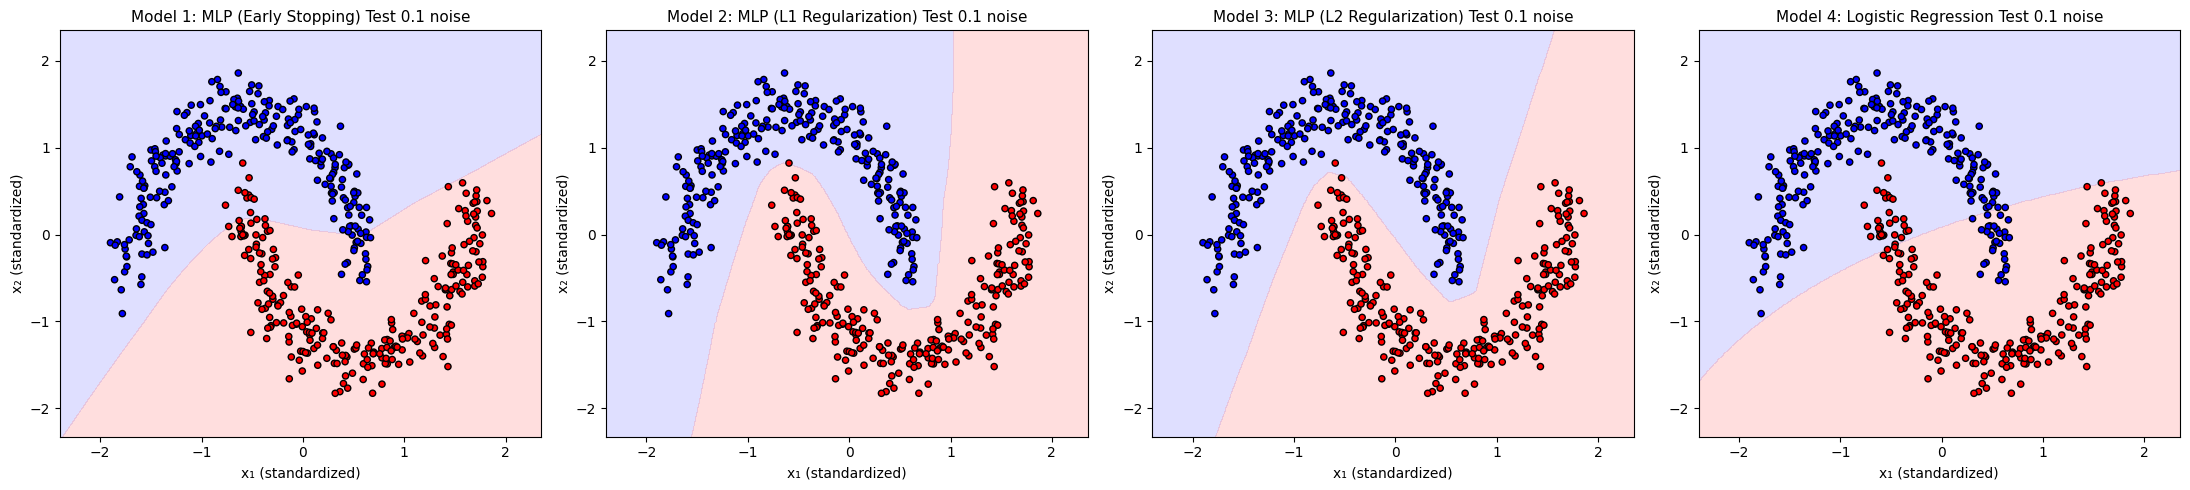

In [73]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x_min, x_max = X_test_01_std[:, 0].min() - 0.5, X_test_01_std[:, 0].max() + 0.5
y_min, y_max = X_test_01_std[:, 1].min() - 0.5, X_test_01_std[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]

# --- Model 1 predictions ---
Z1 = mlp_es.predict_proba(grid)[:, 1].reshape(xx.shape)

# --- Model 2 predictions (PyTorch L1 MLP) ---
probs2 = predict_probs(best_model, torch.from_numpy(grid.astype(np.float32)).to(device))
Z2 = (probs2 >= 0.5).astype(int).reshape(xx.shape)

# --- Model 3 predictions (L2 MLP) ---
Z3 = mlp.predict(grid).reshape(xx.shape)

# --- Model 4 predictions (Logistic Regression with polynomial features) ---
Z4 = logreg.predict(poly.transform(grid)).reshape(xx.shape)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
titles = [
    "Model 1: MLP (Early Stopping) Test 0.1 noise",
    "Model 2: MLP (L1 Regularization) Test 0.1 noise",
    "Model 3: MLP (L2 Regularization) Test 0.1 noise",
    "Model 4: Logistic Regression Test 0.1 noise"
]

Z_list = [Z1, Z2, Z3, Z4]
for ax, Z, title in zip(axes, Z_list, titles):
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap='bwr', alpha=0.25)
    ax.scatter(X_test_01_std[:, 0], X_test_01_std[:, 1],
               c=y_test01, cmap='bwr', edgecolor='k', s=20)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x₁ (standardized)")
    ax.set_ylabel("x₂ (standardized)")

plt.tight_layout()
plt.show()

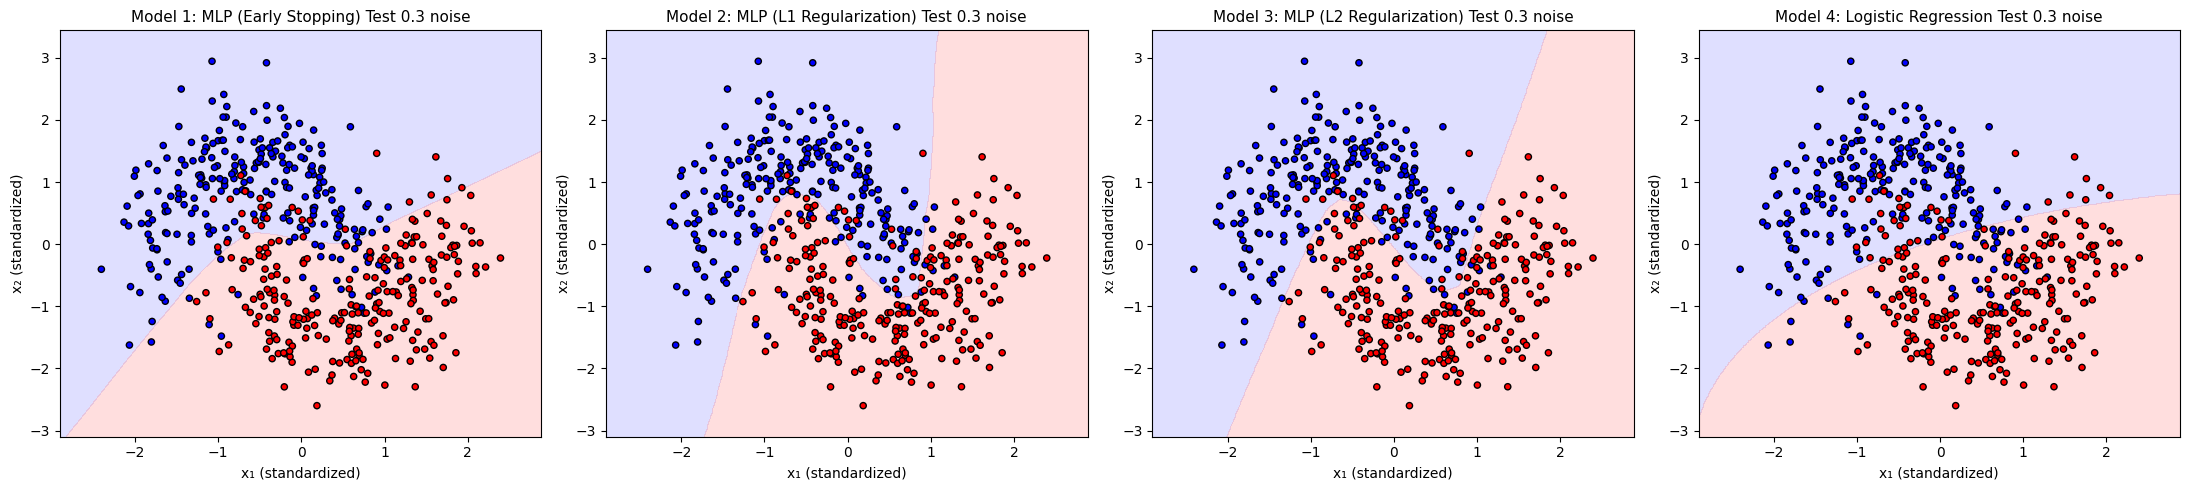

In [74]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x_min, x_max = X_test_03_std[:, 0].min() - 0.5, X_test_03_std[:, 0].max() + 0.5
y_min, y_max = X_test_03_std[:, 1].min() - 0.5, X_test_03_std[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]

# --- Model 1 predictions ---
Z1 = mlp_es.predict_proba(grid)[:, 1].reshape(xx.shape)

# --- Model 2 predictions (PyTorch L1 MLP) ---
probs2 = predict_probs(best_model, torch.from_numpy(grid.astype(np.float32)).to(device))
Z2 = (probs2 >= 0.5).astype(int).reshape(xx.shape)

# --- Model 3 predictions (L2 MLP) ---
Z3 = mlp.predict(grid).reshape(xx.shape)

# --- Model 4 predictions (Logistic Regression with polynomial features) ---
Z4 = logreg.predict(poly.transform(grid)).reshape(xx.shape)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
titles = [
    "Model 1: MLP (Early Stopping) Test 0.3 noise",
    "Model 2: MLP (L1 Regularization) Test 0.3 noise",
    "Model 3: MLP (L2 Regularization) Test 0.3 noise",
    "Model 4: Logistic Regression Test 0.3 noise"
]

Z_list = [Z1, Z2, Z3, Z4]
for ax, Z, title in zip(axes, Z_list, titles):
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap='bwr', alpha=0.25)
    ax.scatter(X_test_03_std[:, 0], X_test_03_std[:, 1],
               c=y_test03, cmap='bwr', edgecolor='k', s=20)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x₁ (standardized)")
    ax.set_ylabel("x₂ (standardized)")

plt.tight_layout()
plt.show()